In [1]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [2]:
df_train = kagglehub.dataset_load(adapter=KaggleDatasetAdapter.PANDAS,
                                  handle='house-prices-advanced-regression-techniques', path='train.csv')
df_test = kagglehub.dataset_load(adapter=KaggleDatasetAdapter.PANDAS, handle='house-prices-advanced-regression-techniques', path='test.csv')


In [3]:
from sklearn.pipeline import Pipeline

In [4]:
import yellowbrick

In [5]:
# a sequence of transformers followed by an estimator
# transformer: fit and transform

In [6]:
from sklearn.model_selection import train_test_split

# Load only the Kaggle 'train.csv'
X = df_train.drop('SalePrice', axis=1)
y = df_train['SalePrice']

# Split the data we HAVE into two
# X_local_test is what we use for our ggplot residuals
X_train, X_local_test, y_train, y_local_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data as an input, sequentially apply a list of transformers and a final estimator. Predictions as output.



In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn import set_config

# 1. Enable visual diagram mode
set_config(display="diagram")

# 2. Define the Numeric Branch
# We name the steps 'imputer' and 'scaler'
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median"))
    , ('scaler', StandardScaler())
])

# 3. Define the Categorical Branch
# We name the steps 'imputer' and 'encoder'
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="constant", fill_value="missing"))
    , ('encoder', OneHotEncoder(handle_unknown="ignore"))
])

# 4. Combine into a named Preprocessor
# We label these transformations 'num' and 'cat'
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include="number")),
        ('cat', categorical_transformer, make_column_selector(dtype_include="object"))
    ]
)

# 5. Build the Final Pipeline with explicit names
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 6. Fit the model
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder

# 1. Start with your existing 'clf' pipeline
# We use your previous full-form pipeline as the base template.

# 2. Define the Param Grid
# Note the naming convention: 'preprocessor__cat__encoder'
# matches the names we gave our steps!
param_grid = [
    {
        # Choice A: OneHotEncoding
        'preprocessor__cat__encoder': [OneHotEncoder(handle_unknown="ignore")]
    },
    {
        # Choice B: OrdinalEncoding
        'preprocessor__cat__encoder': [OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)]
    },
    {
        # Choice C: Skip encoding (drop categories)
        'preprocessor__cat': ['drop']
    }
]

# 3. Initialize Grid Search
# 'cv=5' means it will test each version 5 different times to be sure
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='r2', verbose=1)

# 4. Run the competition
grid_search.fit(X_train, y_train)

# 5. See the winner!
print(f"Best strategy: {grid_search.best_params_}")
print(f"Best R2 Score: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best strategy: {'preprocessor__cat': 'drop'}
Best R2 Score: 0.760


In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# 1. Update the pipeline to use Ridge (it has the 'alpha' parameter)
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# 2. Define a wider search space
param_grid = {
    # Testing Categorical Strategies
    'preprocessor__cat__encoder': [
        OneHotEncoder(handle_unknown="ignore"),
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    ],

    # Testing Numeric Imputation
    'preprocessor__num__imputer__strategy': ['mean', 'median'],

    # Testing Model Strength (Alpha: higher = more "cautious" model)
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}

# 3. Search
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'preprocessor__cat__encoder': OneHotEncoder(handle_unknown='ignore'), 'preprocessor__num__imputer__strategy': 'mean', 'regressor__alpha': 10.0}


In [10]:
# Extract the winner
best_model = grid_search.best_estimator_

# See the weights of the best version
feature_names = best_model['preprocessor'].get_feature_names_out()
weights = best_model['regressor'].coef_

# Match them up
importance = pd.Series(weights, index=feature_names).sort_values()
print(importance)

cat__RoofMatl_ClyTile       -26729.578153
cat__PoolQC_Gd              -22290.314047
cat__Condition2_PosN        -21383.671989
cat__Neighborhood_Edwards   -14294.013780
cat__LandContour_Bnk        -13799.451725
                                 ...     
cat__BsmtQual_Ex             17628.118913
cat__Neighborhood_NridgHt    18726.997631
cat__PoolQC_Ex               19826.034465
cat__Neighborhood_StoneBr    24488.898211
cat__Neighborhood_NoRidge    25142.043461
Length: 302, dtype: float64


In [11]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Update the Numeric Branch to include Interaction Terms
# 'include_bias=False' prevents adding an unnecessary column of 1s
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), # The new "glasses"
    ('scaler', StandardScaler())
])

# 2. Re-assemble the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include="number")),
        ('cat', categorical_transformer, make_column_selector(dtype_include="object"))
    ]
)

# 3. Final Pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# 4. Search for the best complexity
# We check if 'degree 2' (interactions) is better than 'degree 1' (original features)
param_grid = {
    'preprocessor__num__poly__degree': [1, 2],
    'regressor__alpha': [1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2], 'regressor__alpha': [1.0, 10.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sco

In [12]:
# Get the new, expanded feature names
best_model = grid_search.best_estimator_
feature_names = best_model['preprocessor'].get_feature_names_out()

# See which combination is the most "powerful"
weights = best_model['regressor'].coef_
importance = pd.Series(weights, index=feature_names).sort_values(ascending=False)

print("Top 5 Positive Interactions/Features:")
importance

Top 5 Positive Interactions/Features:


cat__Neighborhood_NoRidge    25086.005264
cat__Neighborhood_StoneBr    24458.851029
cat__PoolQC_Ex               19834.922027
cat__Neighborhood_NridgHt    18724.231898
cat__BsmtQual_Ex             17608.407045
                                 ...     
cat__LandContour_Bnk        -13801.422110
cat__Neighborhood_Edwards   -14288.294329
cat__Condition2_PosN        -21406.478981
cat__PoolQC_Gd              -22298.762284
cat__RoofMatl_ClyTile       -26733.221904
Length: 302, dtype: float64

In [13]:
from plotnine import ggplot, aes, geom_point, geom_hline, geom_histogram, labs, theme_minimal, facet_wrap
import pandas as pd

# 1. Use the winning pipeline to predict on your LOCAL test set (the 20% split)
y_local_pred = grid_search.best_estimator_.predict(X_local_test)

# 2. Build a Tidy DataFrame for ggplot
diagnostic_df = pd.DataFrame({
    'actual': y_local_test,
    'predicted': y_local_pred,
    'residuals': y_local_test - y_local_pred
})

# Add back original features if you want to see errors by category (e.g., Sex or Pclass)
# diagnostic_df['pclass'] = X_local_test['pclass'].astype(str)

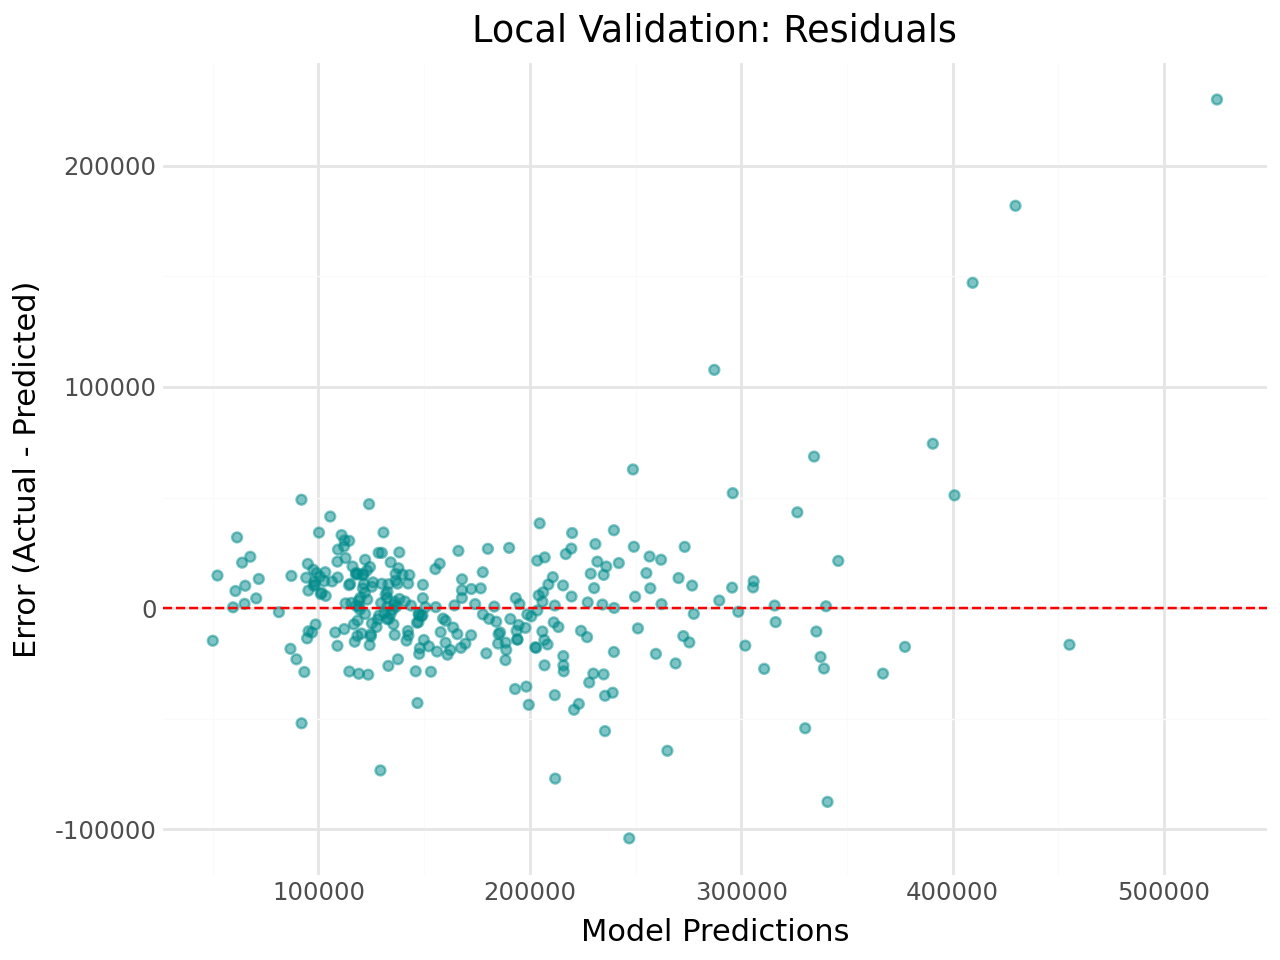

In [14]:
# The classic Residual Plot
res_plot = (
    ggplot(diagnostic_df, aes(x='predicted', y='residuals'))
    + geom_point(alpha=0.5, color="darkcyan")
    + geom_hline(yintercept=0, color="red", linetype="dashed")
    + labs(
        title="Local Validation: Residuals",
        x="Model Predictions",
        y="Error (Actual - Predicted)"
    )
    + theme_minimal()
)

res_plot

In [15]:
from sklearn.inspection import permutation_importance

# 1. Run the permutation (shuffling each column 10 times to get an average)
result = permutation_importance(
    grid_search.best_estimator_,
    X_local_test,
    y_local_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# 2. Organize into a Tidy DataFrame for ggplot
importance_df = pd.DataFrame({
    'feature': X_local_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

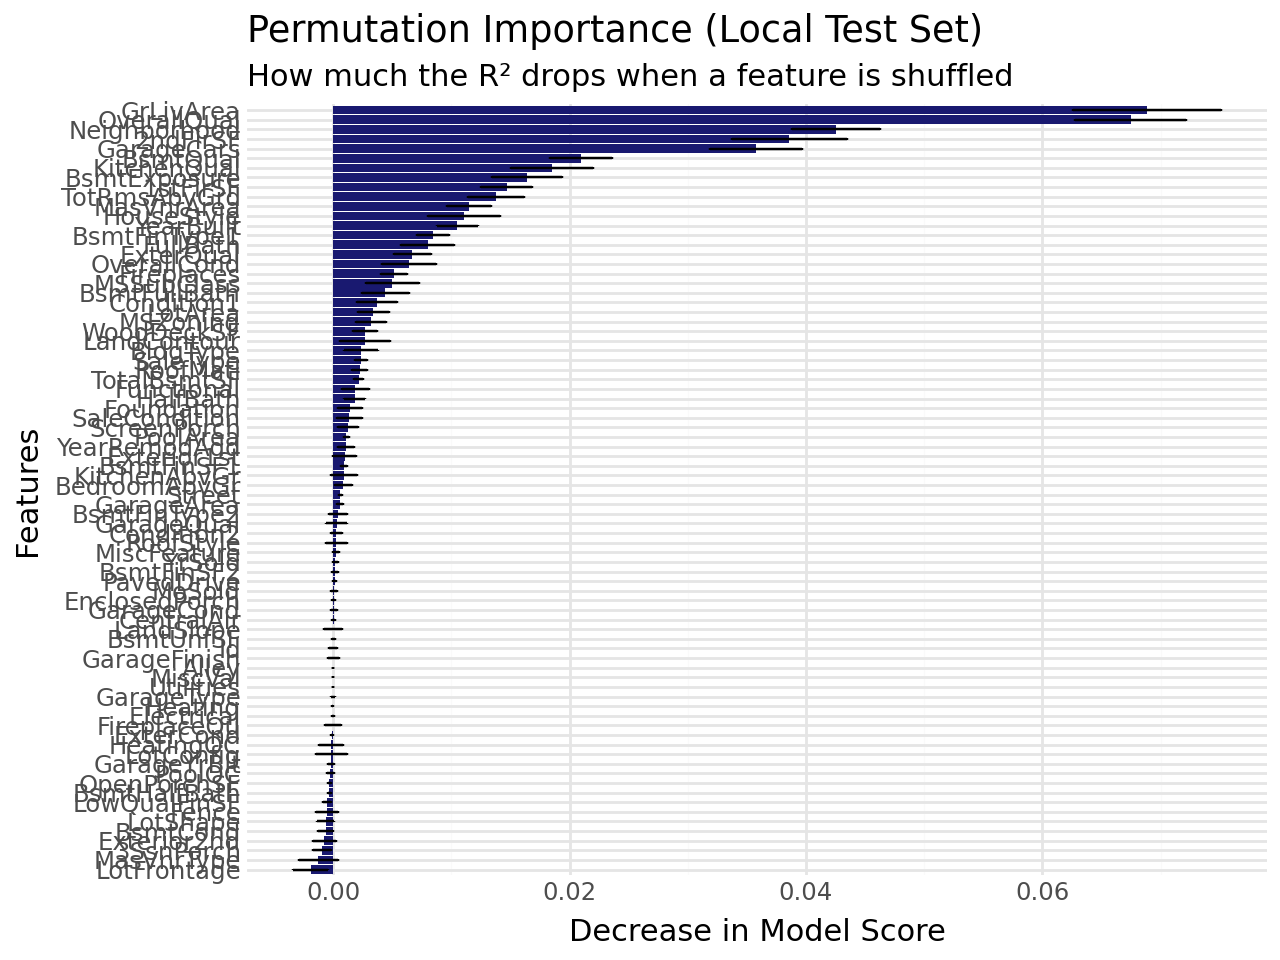

In [16]:
from plotnine import ggplot, aes, geom_col, coord_flip, labs, theme_minimal, geom_errorbar

# We use coord_flip() because feature names are easier to read on the y-axis
importance_plot = (
    ggplot(importance_df, aes(x='reorder(feature, importance_mean)', y='importance_mean'))
    + geom_col(fill="midnightblue")
    + geom_errorbar(
        aes(ymin='importance_mean - importance_std', ymax='importance_mean + importance_std'),
        width=0.2
    )
    + coord_flip()
    + labs(
        title="Permutation Importance (Local Test Set)",
        subtitle="How much the R² drops when a feature is shuffled",
        x="Features",
        y="Decrease in Model Score"
    )
    + theme_minimal()
)

importance_plot

In [17]:
from sklearn.feature_selection import SelectKBest, f_regression

# 1. Create a new version of your pipeline with a 'selector' step
# We use f_regression to pick the top 5 features based on statistical significance
simple_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_regression, k=5)), # Keep only the best 5
    ('regressor', Ridge(alpha=10.0))
])

# 2. Fit on your local training data
simple_clf.fit(X_train, y_train)

# 3. Check the score vs your complex model
print(f"Complex Model Score: {grid_search.best_score_:.3f}")
print(f"Simplified Model Score: {simple_clf.score(X_local_test, y_local_test):.3f}")

Complex Model Score: 0.816
Simplified Model Score: 0.813


In [18]:
# Get the names from the preprocessor
all_names = simple_clf.named_steps['preprocessor'].get_feature_names_out()

# Get a boolean mask of which ones the selector kept
selected_mask = simple_clf.named_steps['selector'].get_support()

# The winning features
winning_features = all_names[selected_mask]
print("The Survival of the Fittest Winners:")
print(winning_features)

The Survival of the Fittest Winners:
['num__OverallQual^2' 'num__OverallQual YearBuilt'
 'num__OverallQual GrLivArea' 'num__OverallQual GarageCars'
 'num__GrLivArea GarageCars']


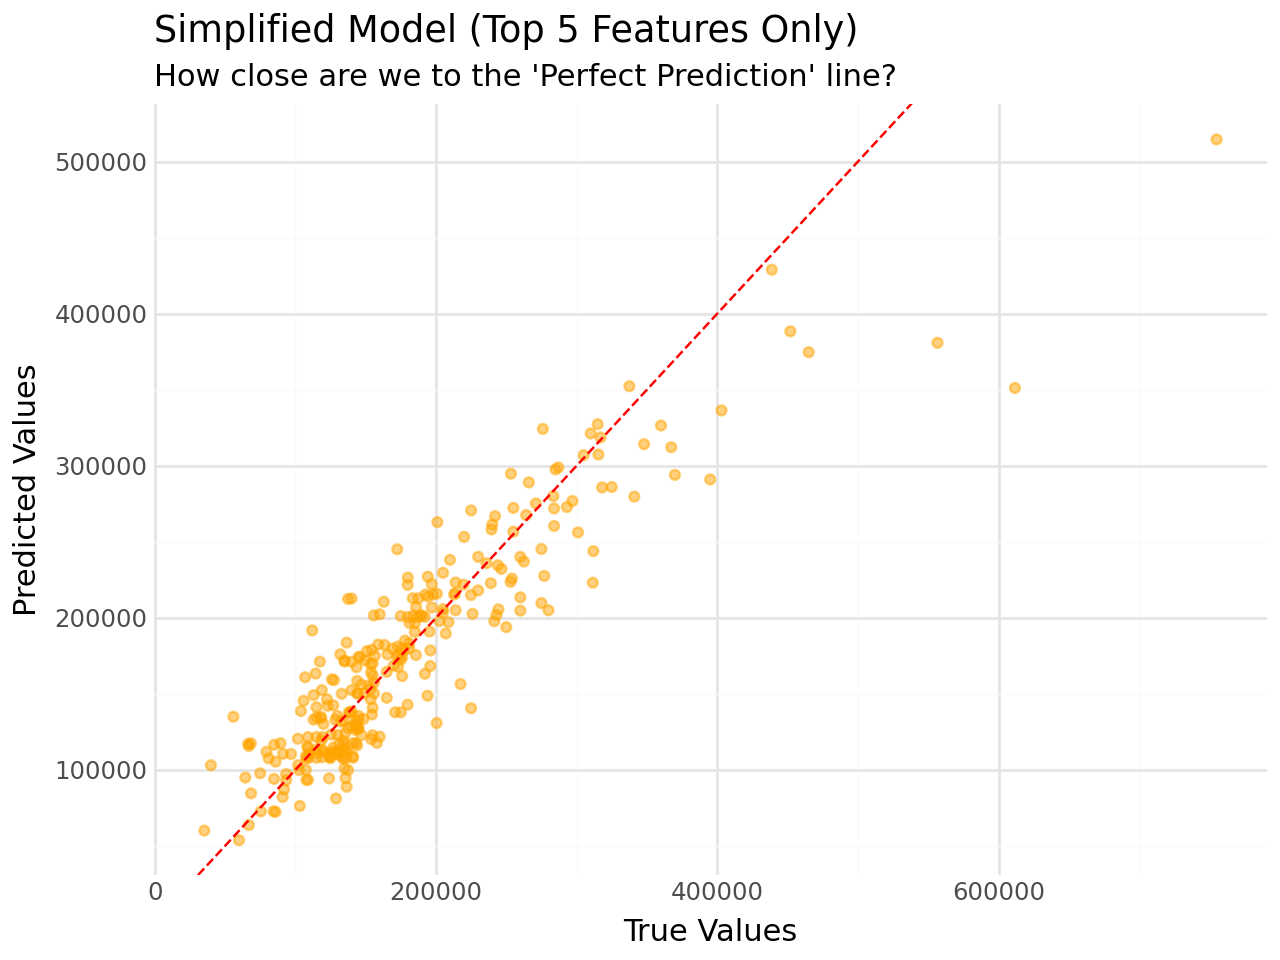

In [19]:
from plotnine import ggplot, aes, geom_point, geom_abline, labs, theme_minimal

simple_preds = simple_clf.predict(X_local_test)
comparison_df = pd.DataFrame({
    'actual': y_local_test,
    'predicted': simple_preds
})

(
    ggplot(comparison_df, aes(x='actual', y='predicted'))
    + geom_point(alpha=0.5, color="orange")
    + geom_abline(intercept=0, slope=1, color="red", linetype="dashed")
    + labs(
        title="Simplified Model (Top 5 Features Only)",
        subtitle="How close are we to the 'Perfect Prediction' line?",
        x="True Values",
        y="Predicted Values"
    )
    + theme_minimal()
)

In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
from plotnine import (ggplot, aes, geom_point, geom_hline, geom_col,
                      coord_flip, labs, theme_minimal, geom_errorbar)

def interrogate_model(model, X_train, y_train, X_test, y_test):
    """
    Runs a 4-phase interrogation on a trained Scikit-Learn pipeline.
    Expects X_train and X_test to be pandas DataFrames.
    """
    # Generate predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # ---------------------------------------------------------
    # PHASE 1: The Sanity Check (Generalization)
    # ---------------------------------------------------------
    print("==================================================")
    print(" PHASE 1: SANITY CHECK (R² Score)")
    print("==================================================")
    train_score = r2_score(y_train, train_preds)
    test_score = r2_score(y_test, test_preds)

    print(f"Training Score: {train_score:.3f}")
    print(f"Testing Score:  {test_score:.3f}")

    drop_off = train_score - test_score
    if drop_off > 0.10:
        print(f"⚠️ WARNING: High drop-off ({drop_off:.3f}). Model is likely overfitting.")
    elif drop_off < -0.05:
        print("⚠️ WARNING: Test score is significantly higher than Train. Check for data leakage.")
    else:
        print("✅ Model shows healthy generalization.")

    # Create a Tidy DataFrame for the remaining phases
    results_df = X_test.copy()
    results_df['Actual'] = y_test
    results_df['Predicted'] = test_preds
    results_df['Residual'] = y_test - test_preds
    results_df['Abs_Error'] = np.abs(results_df['Residual'])

    # ---------------------------------------------------------
    # PHASE 2: The Blind Spot (Residual Analysis)
    # ---------------------------------------------------------
    print("\n==================================================")
    print(" PHASE 2: THE BLIND SPOT (Generating Plot...)")
    print("==================================================")

    res_plot = (
        ggplot(results_df, aes(x='Predicted', y='Residual'))
        + geom_point(alpha=0.5, color="#0072B2")
        + geom_hline(yintercept=0, color="#D55E00", linetype="dashed", size=1)
        + labs(
            title="Residual Analysis: Are errors random?",
            x="Predicted Values",
            y="Residuals (Actual - Predicted)"
        )
        + theme_minimal()
    )
    print(res_plot) # In a Jupyter notebook, this renders the ggplot

    # ---------------------------------------------------------
    # PHASE 3: The Lie Detector (Permutation Importance)
    # ---------------------------------------------------------
    print("\n==================================================")
    print(" PHASE 3: THE LIE DETECTOR (Calculating...)")
    print("==================================================")

    # Run permutation (5 shuffles per column)
    pi = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

    imp_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': pi.importances_mean,
        'Std': pi.importances_std
    }).sort_values('Importance', ascending=False)

    # Grab just the top 10 to keep the plot clean
    top_10_imp = imp_df.head(10)

    imp_plot = (
        ggplot(top_10_imp, aes(x='reorder(Feature, Importance)', y='Importance'))
        + geom_col(fill="#009E73")
        + geom_errorbar(aes(ymin='Importance - Std', ymax='Importance + Std'), width=0.2)
        + coord_flip()
        + labs(
            title="Top 10 Permutation Importances",
            subtitle="How much the score drops when a feature is randomized",
            x="Original Feature",
            y="Decrease in R² Score"
        )
        + theme_minimal()
    )
    print(imp_plot)

    # Check for negative importance (features hurting the model)
    bad_features = imp_df[imp_df['Importance'] < 0]['Feature'].tolist()
    if bad_features:
        print(f"⚠️ Consider dropping these features (Negative Importance): {bad_features[:5]}")

    # ---------------------------------------------------------
    # PHASE 4: The Worst-Case Check (Error Sorting)
    # ---------------------------------------------------------
    print("\n==================================================")
    print(" PHASE 4: THE WORST-CASE CHECK")
    print("==================================================")
    print("Top 5 largest prediction errors:")

    # Sort by the biggest absolute mistakes
    worst_cases = results_df.sort_values(by='Abs_Error', ascending=False).head(5)

    # Reorder columns so the target and predictions are first, followed by the features
    display_cols = ['Actual', 'Predicted', 'Abs_Error'] + list(X_test.columns)

    # Display the result (using pandas built-in display if in a notebook)
    try:
        from IPython.display import display
        display(worst_cases[display_cols])
    except ImportError:
        print(worst_cases[display_cols].to_string())

    return results_df # Return the tidy dataframe in case you want to do more digging

In [21]:
# 1. Build & Fit your pipeline
clf.fit(X_train, y_train)

# 2. Run the interrogation
diagnostics = interrogate_model(clf, X_train, y_train, X_local_test, y_local_test)

# 3. Read the output, adjust your pipeline (add log transforms, drop bad features), and repeat!

 PHASE 1: SANITY CHECK (R² Score)
Training Score: 0.978
Testing Score:  0.840
⚠️ WARNING: High drop-off (0.138). Model is likely overfitting.

 PHASE 2: THE BLIND SPOT (Generating Plot...)
<ggplot: (640 x 480)>

 PHASE 3: THE LIE DETECTOR (Calculating...)
<ggplot: (640 x 480)>
⚠️ Consider dropping these features (Negative Importance): ['CentralAir', 'YrSold', 'BsmtFinType2', 'MSZoning', 'RoofStyle']

 PHASE 4: THE WORST-CASE CHECK
Top 5 largest prediction errors:


,Actual,Predicted,Abs_Error,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
744,180000,358528.675848,178528.675848,745,120,RL,41.0,5395,Pave,NaN,...,0,0,NaN,NaN,NaN,0,10,2008,WD,Normal
588,143000,293058.108959,150058.108959,589,20,RL,65.0,25095,Pave,NaN,...,60,0,NaN,NaN,NaN,0,6,2009,WD,Partial
322,301000,155105.421404,145894.578596,323,60,RL,86.0,10380,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,8,2007,WD,Normal
451,280000,135701.944090,144298.055910,452,20,RL,62.0,70761,Pave,NaN,...,0,0,NaN,NaN,NaN,0,12,2006,WD,Normal
898,611657,479066.943901,132590.056099,899,20,RL,100.0,12919,Pave,NaN,...,0,0,NaN,NaN,NaN,0,3,2010,New,Partial
